<h1>Project 1: Data Analysis Project<h1>

<h2> 1 Inequality in Denmark

### 1.1 The Gini coefficient and the top 10 percent share

In [ ]:
# %pip install --upgrade git+https://github.com/alemartinello/dstapi
# %pip install --upgrade fredapi

  Cloning https://github.com/alemartinello/dstapi to /private/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/pip-req-build-6b6xtzii
  Running command git clone --filter=blob:none --quiet https://github.com/alemartinello/dstapi /private/var/folders/9f/_qwhm7hj7nx54tbqjl50k1900000gn/T/pip-req-build-6b6xtzii
  Resolved https://github.com/alemartinello/dstapi to commit d9eeb5a82cbc70b7d63b2ff44d92632fd77123a4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Melissa test environment issues -- disregard
from dstapi import DstApi

api = DstApi('IFOR41')
print(type(api))

summary = api.tablesummary(language='en')
print(summary.head())

<class 'dstapi.dstapi.DstApi'>
Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00
  variable name  # values First value First value label Last value  \
0         ULLIG         4          70  Gini coefficient         73   
1     KOMMUNEDK        99         000       All Denmark        851   
2           Tid        38        1987              1987       2024   

                                  Last value label  Time variable  
0  P90/10 (Upper decile boundary divided by lower)          False  
1                                          Aalborg          False  
2                                             2024           True  


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from dstapi import DstApi
import pandas as pd

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})


In [4]:
IFOR41 = DstApi('IFOR41')
IFOR41.tablesummary(language='en')


Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [5]:
IFOR41.variable_levels('ULLIG',language='en') ##might not be necessary

,id,text
0,70,Gini coefficient
1,71,Hoover index
2,72,S80/S20 (Income quintile share ratio)
3,73,P90/10 (Upper decile boundary divided by lower)


In [6]:
params = {
    'table': 'IFOR41',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

ginidk = IFOR41.get_data(params=params)
ginidk.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,All Denmark,1999,23.83
2,Gini coefficient,All Denmark,1988,22.06
3,Gini coefficient,All Denmark,2015,28.77
4,Gini coefficient,All Denmark,1989,21.93


In [7]:
ginidk=ginidk.drop(columns=['ULLIG','KOMMUNEDK'])
ginidk = ginidk.rename(columns={'INDHOLD':'gini', 'TID': 'year'})
ginidk= ginidk.set_index('year').sort_index()

ginidk.head(5)

,gini
year,
1987,22.07
1988,22.06
1989,21.93
1990,22.16
1991,21.99


Text(0, 0.5, 'Gini')

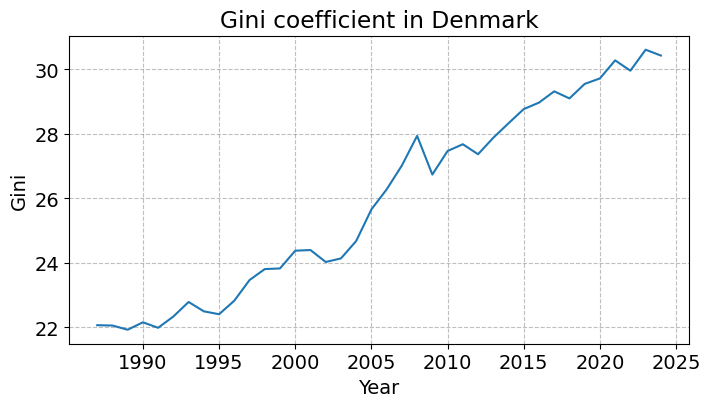

In [8]:
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot()
ax.plot(ginidk.index,ginidk['gini'].astype(float))
ax.set_title('Gini coefficient in Denmark')
ax.set_xlabel('Year')
ax.set_ylabel('Gini')

In [9]:
IFOR32 = DstApi('IFOR32')
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [10]:
params = {
    'table': 'IFOR32',
    'format': 'BULK', 
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['000']},
        {'code': 'Tid', 'values': ['*']}, 
        ]
    }

df = IFOR32.get_data(params=params)
df.head(10)
df.tail(10)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
370,First decil,All Denmark,2001,62629
371,Second decil,All Denmark,2001,98552
372,Third decil,All Denmark,2001,114430
373,Fourth decil,All Denmark,2001,129885
374,Fifth decil,All Denmark,2001,144273
375,Sixth decil,All Denmark,2001,158392
376,Seventh decil,All Denmark,2001,173884
377,Eigth decil,All Denmark,2001,193021
378,Ninth decil,All Denmark,2001,221638
379,Tenth decil,All Denmark,2001,338942


In [11]:
df=df.drop(columns=['KOMMUNEDK'])
df = df.rename(columns={'INDHOLD':'income', 'TID': 'year'})
df= df.set_index('year').sort_index()

df.head(5)

,DECILGEN,income
year,,
1987,First decil,31418
1987,Ninth decil,123582
1987,Eigth decil,110184
1987,Seventh decil,100691
1987,Sixth decil,92777


<Axes: title={'center': 'Top 10% income share in Denmark'}, xlabel='Year', ylabel='Share of total income'>

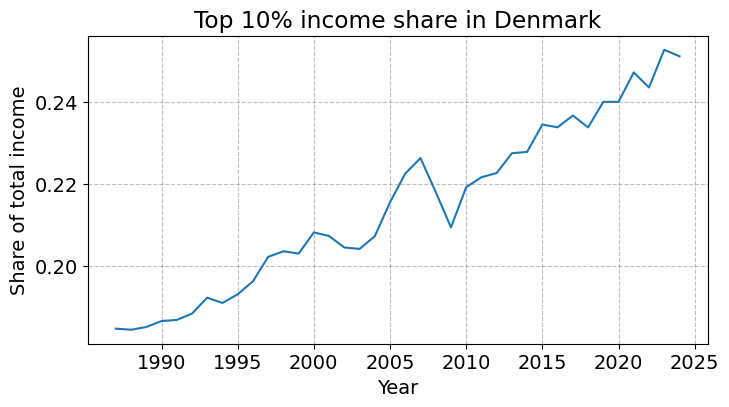

In [12]:
pivot = df.pivot_table(values='income', index=df.index, columns='DECILGEN', aggfunc='sum')
top10_share = pivot['Tenth decil'] / pivot.sum(axis=1)

top10_share.plot(title='Top 10% income share in Denmark', ylabel='Share of total income', xlabel='Year', figsize=(8,4))

#Describe how inequality in Denmark has developed since 1987. Do the two measures
tell the same story? 

Both graphs show gradually increasing inequality from 1987 to 2000, a slight dip from 2000 to ~2003 followed by a sharp spike that peaked immediately before the financial crisis and sharply fell during it, before continuing on its previous trend of gradually increasing from 2010-2024.


In [13]:
#Compute the correlation between them over time
print(np.corrcoef(ginidk['gini'].astype(float), top10_share)[0,1])





0.9816415450527721


### 1.2 Prediction

In [14]:
# Importing the packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [15]:
# Settting up the code for the prediction

y=ginidk['gini'].astype(float).values
t=ginidk.index.astype(int).values-1987

S1= lambda beta: sum((y-(beta[0]+beta[1]*t))**2)
S2= lambda beta: sum((y-(beta[0]+beta[1]*t+beta[2]*t**2))**2)

In [16]:
# Solving the minimization problem

minproblin = minimize(S1, x0=(0,0),constraints=None)
minprobqua = minimize(S2, x0=(0,0,0),constraints=None)

beta0_lin, beta1_lin = minproblin.x
beta0_quad, beta1_quad,beta2_quad = minprobqua.x

print('Beta linear=', beta0_lin, beta1_lin)
print('Beta quadratic=', beta0_quad, beta1_quad, beta2_quad)

Beta linear= 21.042753545648125 0.26354959467635763
Beta quadratic= 21.304186697307134 0.21997579816762736 0.0011776761712922607


In [17]:
# Checking our answers against np.polyfit

coeff_lin= np.polyfit(t,y,1)
print(coeff_lin)

coeff_quad=np.polyfit(t,y,2)
print(coeff_quad)

[ 0.26354962 21.04275304]
[1.17769085e-03 2.19975061e-01 2.13042004e+01]


When looking at the minimization an the np.polyfit against eachother they both return the same coefficient. This indicate that we have done the minimization problem correct.

Text(0, 0.5, 'Gini')

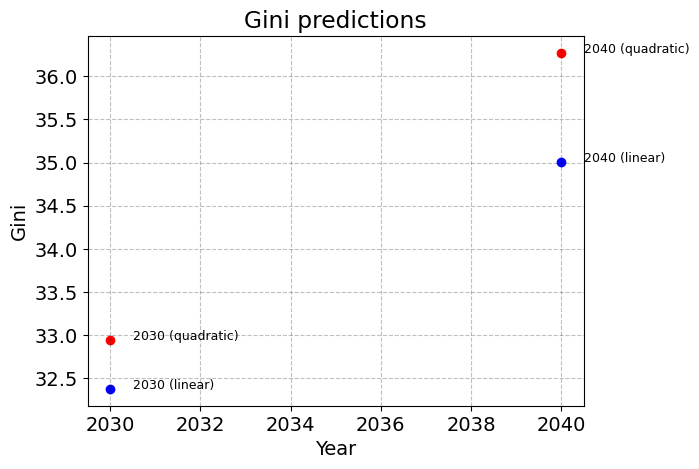

In [18]:
# Predicting an plotting the Gini coefficient in 2030 and 2040

t2030 = 2030-1987
t2040 = 2040-1987

# To find y we set y to the formula p1 and p2 because the difference 
# bewteen them should be 0 if the formula is correctly minimized

lin_gin2030 = beta0_lin + beta1_lin * t2030
lin_gin2040 = beta0_lin + beta1_lin * t2040
quad_gin2030 = beta0_quad + beta1_quad * t2030 + beta2_quad * t2030**2
quad_gin2040 = beta0_quad + beta1_quad * t2040 + beta2_quad * t2040**2

plt.scatter(2030, lin_gin2030, color='blue')
plt.text(2030 + 0.5, lin_gin2030 + 0.001, '2030 (linear)', fontsize=9)

plt.scatter(2040, lin_gin2040, color='blue')
plt.text(2040 + 0.5, lin_gin2040 + 0.001, '2040 (linear)', fontsize=9)

plt.scatter(2030, quad_gin2030, color='red')
plt.text(2030 + 0.5, quad_gin2030 + 0.001, '2030 (quadratic)', fontsize=9)


plt.scatter(2040, quad_gin2040, color='red')
plt.text(2040 + 0.5, quad_gin2040 + 0.001, '2040 (quadratic)', fontsize=9)

plt.title('Gini predictions')
plt.xlabel('Year')
plt.ylabel('Gini')

The plot shows linear and quadratic predictions of the Gini coefficient for 20230 and 2040. In 2030 we see that the two differ around 1,2 in the prediction of the Gini coeffeicient. In 2040 there is a bigger difference between the linear and quadratic gini prediction, around 2,5.The quadratic model has the highest prediction of the Gini coefficient both in 2030 and 2040. This shows that the predictions rely highly on the choice of model. The gini coefficient in Denmark has increased in the last centuries. Therefore, its easy to believe that this development in gini will continue. However, I would not trust the model to predict the gini coefficient, as they are both simple models based on the trend and doesnt include the factors which actually drives the change in the gini coeffiecient such as policy, enplyment and demographics.

### 1.3 Municipalities

#### 1.3.1

In [19]:
IFOR41.tablesummary(language='en')

Table IFOR41: Income distribution on equivalised disposable income by indicator, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,ULLIG,4,70,Gini coefficient,73,P90/10 (Upper decile boundary divided by lower),False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [20]:
# Gini across municipalities

params_muni_gini = {
    'table': 'IFOR41',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'ULLIG', 'values': ['70']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

municip_gini = IFOR41.get_data(params=params_muni_gini)
municip_gini.head(5)

,ULLIG,KOMMUNEDK,TID,INDHOLD
0,Gini coefficient,All Denmark,2016,28.97
1,Gini coefficient,Copenhagen,2016,33.24
2,Gini coefficient,Frederiksberg,2016,34.85
3,Gini coefficient,Ballerup,2016,25.77
4,Gini coefficient,Brøndby,2016,25.71


In [21]:
# Clearing the data

municip_gini = municip_gini.drop(columns = ['ULLIG'])
municip_gini = municip_gini.rename(columns = {'INDHOLD':'gini', 'TID': 'year','KOMMUNEDK': 'municipalities'})
municip_gini =municip_gini.set_index('year').sort_index()

display(municip_gini)

,municipalities,gini
year,,
1987,Hjørring,21.96
1987,Greve,18.64
1987,Køge,19.52
1987,Halsnæs,18.50
1987,Roskilde,20.54
...,...,...
2024,Greve,26.35
2024,Frederikssund,26.11
2024,Egedal,23.85


In [22]:
IFOR32.tablesummary(language='en')

Table IFOR32: Avg. equivalised disposable Income in decile groups, by decile average, municipality and time
Last update: 2025-12-01T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,DECILGEN,10,1DC,First decil,10DC,Tenth decil,False
1,KOMMUNEDK,99,000,All Denmark,851,Aalborg,False
2,Tid,38,1987,1987,2024,2024,True


In [23]:
# Top 10% share across municipalities

params_muni_top10 = {
    'table': 'IFOR32',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'DECILGEN', 'values': ['*']},
        {'code': 'KOMMUNEDK', 'values': ['*']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

municip_top10 = IFOR32.get_data(params=params_muni_top10)
municip_top10.head(5)

,DECILGEN,KOMMUNEDK,TID,INDHOLD
0,Second decil,Odense,2013,123841
1,Third decil,Odense,2013,150153
2,Fourth decil,Odense,2013,170790
3,Fifth decil,Odense,2013,193979
4,Sixth decil,Odense,2013,218942


In [24]:
# Cleaning the data

municip_top10 = municip_top10.rename(columns = {'INDHOLD':'income', 'TID': 'year','KOMMUNEDK': 'municipalities'})
municip_top10 =municip_top10.set_index('year').sort_index()

display(municip_top10)

,DECILGEN,municipalities,income
year,,,
1987,Sixth decil,Bornholm,85526
1987,First decil,Frederikshavn,32887
1987,Second decil,Frederikshavn,59922
1987,Third decil,Frederikshavn,68777
1987,Fourth decil,Frederikshavn,76841
...,...,...,...
2024,Third decil,Faaborg-Midtfyn,213520
2024,Third decil,Kerteminde,212744
2024,Third decil,Nyborg,209481


In [25]:
# Making a pivot table

municip_top10_reset = municip_top10.reset_index()

pivot_muni = municip_top10_reset.pivot_table(
        values = 'income',
        index = ['year', 'municipalities'],
        columns = 'DECILGEN',
        aggfunc = 'sum'
)


municip_top10_share = pivot_muni['Tenth decil'] / pivot.sum(axis=1)

display(municip_top10_share)

year  municipalities 
1987  Aabenraa           0.174965
      Aalborg            0.170437
      Aarhus             0.180832
      Albertslund        0.176451
      All Denmark        0.184549
                           ...   
2024  Vejle              0.236771
      Vesthimmerlands    0.200238
      Viborg             0.208468
      Vordingborg        0.189599
      Ærø                0.176300
Length: 3762, dtype: float64

In [26]:
# Merging the two tables

combined = pd.merge(
        municip_gini.reset_index(),
        municip_top10_share.reset_index(name='top10_share'),
        on= ['year', 'municipalities'],
        how= 'inner'
)

combined =combined.sort_values(['municipalities','year']).reset_index(drop=True)

display(combined)

,year,municipalities,gini,top10_share
0,1987,Aabenraa,21.33,0.174965
1,1988,Aabenraa,21.51,0.174845
2,1989,Aabenraa,20.74,0.174342
3,1990,Aabenraa,20.83,0.175503
4,1991,Aabenraa,20.86,0.180219
...,...,...,...,...
3757,2020,Ærø,25.61,0.175799
3758,2021,Ærø,26.63,0.180296
3759,2022,Ærø,27.02,0.178989
3760,2023,Ærø,27.67,0.177187


In [27]:
# Choosing the types

combined['gini'] = combined['gini'].astype(float)
combined['top10_share'] = combined['top10_share'].astype(float)

In [28]:
# Using grupby to find the year-to-year differences

combined[['diff_gini', 'diff_top10_share']] = combined.groupby('municipalities')[['gini','top10_share']].diff()

combined.head(5)

,year,municipalities,gini,top10_share,diff_gini,diff_top10_share
0,1987,Aabenraa,21.33,0.174965,NaN,NaN
1,1988,Aabenraa,21.51,0.174845,0.18,-0.000121
2,1989,Aabenraa,20.74,0.174342,-0.77,-0.000503
3,1990,Aabenraa,20.83,0.175503,0.09,0.001161
4,1991,Aabenraa,20.86,0.180219,0.03,0.004716


In [29]:
# Printing the mean of the correlation

corr = combined.groupby('municipalities')['diff_gini'].corr(combined['diff_top10_share']).rename('correlation')
mean_correlation = corr.mean()
print(f'{mean_correlation = :.3f}')

mean_correlation = 0.644


In [30]:
# Sorting the values

corr = corr.sort_values()
print(corr)

municipalities
Sønderborg     -0.059326
Brønderslev     0.213366
Assens          0.230789
Kalundborg      0.268913
Guldborgsund    0.292057
                  ...   
Egedal          0.934802
Solrød          0.942683
Vejen           0.967018
Fredensborg     0.974044
Billund         0.995300
Name: correlation, Length: 99, dtype: float64


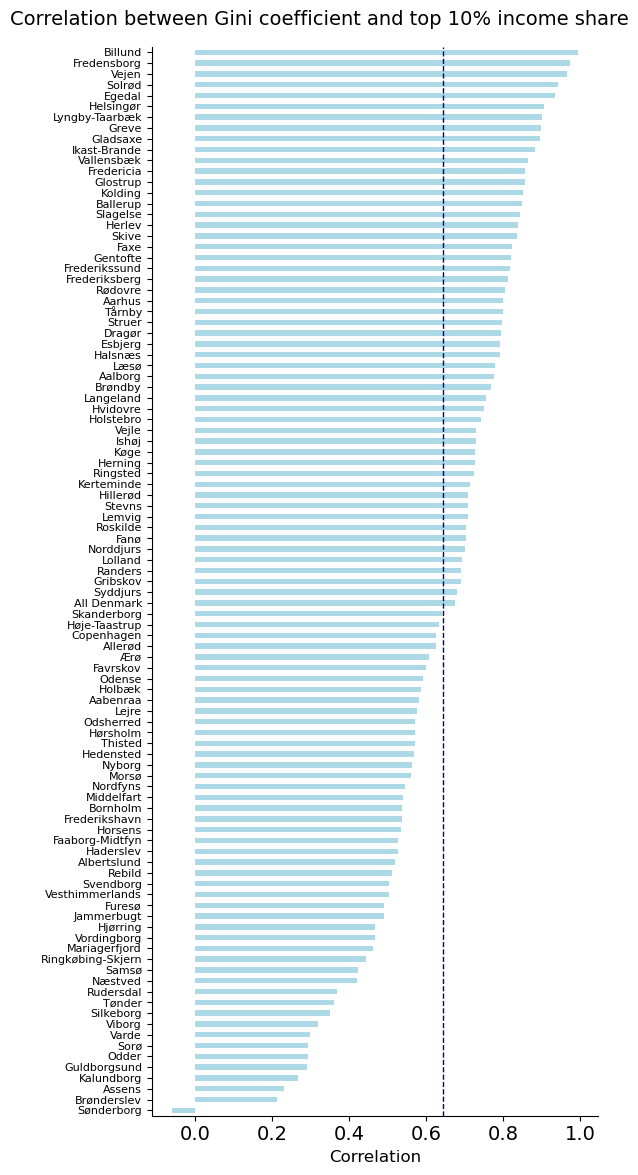

In [31]:
# Plotting the correlation

fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr.index, corr.values, height=0.5, color='lightblue')

ax.axvline(mean_correlation, color='darkblue', linestyle='--', linewidth=1, label=f'Mean ={mean_correlation:.2f}')

ax.set_xlabel('Correlation', fontsize=12)

ax.set_yticks(range(len(corr.index)))
ax.set_yticks(np.arange(len(corr.index))*1)
ax.set_yticklabels(corr.index,fontsize=8)
ax.set_ylim(-0.5,len(corr.index)-0.5)

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

fig.suptitle('Correlation between Gini coefficient and top 10% income share', fontsize=14)
fig.tight_layout()

We see that the correlation between the gini coefficient and the top 10% income share varies alot across the different municipalities. We see almost perfect correaltion in the municippalities Billund & Fredensborg. On the other hand, we also see municipalities with a very small correlation. The mean of the correlation is 0,644 which suggests a fairly strong overall link between the gini coefficient and the top 10% income share. However, the risk of outliers driven by a few high income individuals in small municipalities is worth keeping in mind because it can skew the gini coefficient. Therefore, there is a risk of them bluring the correlation.

#### 1.3.2

In [32]:
#Sorting gini for 2024
gini_2024 = municip_gini.loc[2024].sort_values('gini')

#Finding the smallest and largest gini coefficients
smallest_gini = gini_2024[['municipalities', 'gini']].head(10)
largest_gini = gini_2024[['municipalities', 'gini']].tail(10)

print("10 most equal municipalities: ", smallest_gini)
print("10 most unequal municipalities: ", largest_gini)

10 most equal municipalities:         municipalities   gini
year                        
2024  Faaborg-Midtfyn  23.77
2024           Egedal  23.85
2024         Bornholm  24.03
2024             Faxe  24.09
2024         Favrskov  24.41
2024          Halsnæs  24.41
2024           Assens  24.46
2024        Hedensted  24.58
2024      Albertslund  24.66
2024            Odder  24.70
10 most unequal municipalities:        municipalities   gini
year                       
2024       Helsingør  30.55
2024     Fredensborg  32.76
2024          Aarhus  33.43
2024      Copenhagen  34.97
2024   Frederiksberg  36.54
2024  Lyngby-Taarbæk  39.28
2024        Hørsholm  40.07
2024           Vejen  46.32
2024       Rudersdal  47.31
2024        Gentofte  49.04


#### 1.3.3

In [33]:

municip_gini3 = municip_gini.reset_index()
gini_2024 = municip_gini3[municip_gini3['year'] == 2024][['municipalities', 'gini']].rename(columns={'gini': 'gini_2024'})
gini_1987 = municip_gini3[municip_gini3['year'] == 1987][['municipalities', 'gini']].rename(columns={'gini': 'gini_1987'})

gini_change = gini_2024.merge(gini_1987, on='municipalities', how='inner')


gini_change['gini_change'] = gini_change['gini_2024'].astype(float) - gini_change['gini_1987'].astype(float)

gini_change_sorted = gini_change.sort_values('gini_change', ascending=False)


# Biggest change
print("Biggest change in Gini: ", gini_change_sorted.head(10))

# Smallest change
print("Smallest change in Gini", gini_change.sort_values('gini_change', ascending=True).head(10))

Biggest change in Gini:      municipalities gini_2024 gini_1987  gini_change
7            Vejen     46.32     21.20        25.12
74       Rudersdal     47.31     29.05        18.26
64        Gentofte     49.04     31.10        17.94
57  Lyngby-Taarbæk     39.28     24.97        14.31
69      Copenhagen     34.97     23.05        11.92
73        Hørsholm     40.07     28.39        11.68
50     Fredensborg     32.76     21.17        11.59
39          Aarhus     33.43     22.10        11.33
68   Frederiksberg     36.54     25.28        11.26
53      Vallensbæk     26.70     15.90        10.80
Smallest change in Gini      municipalities gini_2024 gini_1987  gini_change
9              Fanø     26.34     25.67         0.67
15              Ærø     26.98     24.63         2.35
97             Faxe     24.09     21.64         2.45
28             Læsø     25.41     22.81         2.60
75         Bornholm     24.03     21.31         2.72
48  Faaborg-Midtfyn     23.77     20.88         2.89
81      

### 1.4 Extension

In [34]:
# Using table AULP01 for this task - importing the data

AULP01 = DstApi('AULP01')

AULP01.tablesummary(language='en')

Table AULP01: Full-time unemployed persons in per cent of the labour force by region, age, sex and time
Last update: 2026-04-14T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,OMRÅDE,117,000,All Denmark,997,Abroad,False
1,ALDER,10,TOT,"Age, total",6099,60 year and over,False
2,KØN,3,TOT,Total,K,Women,False
3,Tid,19,2007,2007,2025,2025,True


In [35]:
# Setting up the table for AULP01

params = {
    'table': 'AULP01',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'OMRÅDE', 'values': ['*']},
        {'code': 'ALDER', 'values': ['TOT']},
        {'code': 'KØN', 'values': ['TOT']},
        {'code': 'Tid', 'values': ['*']}
    ]
}

unemployment = AULP01.get_data(params=params)
unemployment.head(5)

,OMRÅDE,ALDER,KØN,TID,INDHOLD
0,All Denmark,"Age, total",Total,2013,5.8
1,Province Byen København,"Age, total",Total,2013,6.9
2,Province Københavns omegn,"Age, total",Total,2013,5.9
3,Province Nordsjælland,"Age, total",Total,2013,4.4
4,Province Bornholm,"Age, total",Total,2013,7.0


In [36]:
# Cleaning up the data

unemployment =unemployment.drop(columns= ['ALDER','KØN'])
unemployment = unemployment.rename(columns={'INDHOLD':'unemployment', 'OMRÅDE':'municipality', 'TID':'year'})
unemployment = unemployment.set_index('year').sort_index()

display(unemployment)

,municipality,unemployment
year,,
2007,Ringsted,3.1
2007,Vejen,1.9
2007,Aabenraa,3.8
2007,Fredericia,3.3
2007,Horsens,2.3
...,...,...
2025,Svendborg,2.9
2025,Odense,3.8
2025,Nyborg,3.2


In [37]:
# Sorting in alphabetical order

unemployment = unemployment.reset_index().sort_values(['year', 'municipality']).reset_index(drop=True)
display(unemployment)

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
4,2007,All Denmark,3.6
...,...,...,...
2180,2025,Vejle,2.4
2181,2025,Vesthimmerlands,2.6
2182,2025,Viborg,2.5
2183,2025,Vordingborg,2.9


In [38]:
# Dropping rows

drop_rows = unemployment.municipality.str.contains('Region')
drop_rows |= unemployment.municipality.str.contains('Provience')
drop_rows |= unemployment.municipality.str.contains('All Denmark')
drop_rows |= unemployment.year==2025
unemployment.loc[~drop_rows,:]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6
...,...,...,...
2065,2024,Vejle,2.6
2066,2024,Vesthimmerlands,2.9
2067,2024,Viborg,2.7
2068,2024,Vordingborg,3.0


In [39]:
# Saving the result

unemployment =unemployment.loc[drop_rows==False]
unemployment.iloc[:5,:5]

,year,municipality,unemployment
0,2007,Aabenraa,3.8
1,2007,Aalborg,5.1
2,2007,Aarhus,3.9
3,2007,Albertslund,4.8
5,2007,Allerød,1.6


In [40]:
# Using table IFOR41 for the gini coefficient
# Resetting the index to use for this task

municip_gini4 = municip_gini.reset_index()

display(municip_gini4)

,year,municipalities,gini
0,1987,Hjørring,21.96
1,1987,Greve,18.64
2,1987,Køge,19.52
3,1987,Halsnæs,18.50
4,1987,Roskilde,20.54
...,...,...,...
3757,2024,Greve,26.35
3758,2024,Frederikssund,26.11
3759,2024,Egedal,23.85
3760,2024,Faxe,24.09


In [41]:
# Dropping rows

drop_rows = municip_gini4.year.between(1987,2006)
drop_rows |= municip_gini4.municipalities.str.contains('All Denmark')

municip_gini5 = municip_gini4.loc[~drop_rows,:]
display(municip_gini5)

,year,municipalities,gini
1980,2007,Odsherred,23.21
1981,2007,Egedal,21.07
1982,2007,Frederikssund,23.47
1983,2007,Greve,24.48
1984,2007,Køge,22.85
...,...,...,...
3757,2024,Greve,26.35
3758,2024,Frederikssund,26.11
3759,2024,Egedal,23.85
3760,2024,Faxe,24.09


In [42]:
# Merging the two tables

unemployment2 = unemployment.rename(columns = {'municipality': 'municipalities'})

combined1 = pd.merge(
        unemployment2.reset_index(drop=True),
        municip_gini5.reset_index(drop=True),
        on= ['year', 'municipalities'],
        how= 'inner'
)

combined =combined.sort_values(['municipalities','year']).reset_index(drop=True)

display(combined1)

,year,municipalities,unemployment,gini
0,2007,Aabenraa,3.8,25.36
1,2007,Aalborg,5.1,26.07
2,2007,Aarhus,3.9,30.03
3,2007,Albertslund,4.8,23.34
4,2007,Allerød,1.6,25.00
...,...,...,...,...
1759,2024,Vejle,2.6,27.78
1760,2024,Vesthimmerlands,2.9,26.40
1761,2024,Viborg,2.7,26.07
1762,2024,Vordingborg,3.0,25.84


In [43]:
# Setting up the type

combined1['unemployment'] = combined1['unemployment'].astype(float)
combined1['gini'] = combined1['gini'].astype(float)

In [44]:
# Using grupby to find the year-to-year differences

combined1[['diff_unemployment', 'diff_gini']] = combined1.groupby('municipalities')[['unemployment','gini',]].diff()

combined1.head(5)

,year,municipalities,unemployment,gini,diff_unemployment,diff_gini
0,2007,Aabenraa,3.8,25.36,NaN,NaN
1,2007,Aalborg,5.1,26.07,NaN,NaN
2,2007,Aarhus,3.9,30.03,NaN,NaN
3,2007,Albertslund,4.8,23.34,NaN,NaN
4,2007,Allerød,1.6,25.00,NaN,NaN


In [45]:
# Printing the mean of the correlation

corr1 = combined1.groupby('municipalities')['diff_unemployment'].corr(combined1['diff_gini']).rename('correlation1')
mean_correlation1 = corr1.mean()
print(f'{mean_correlation1 = :.3f}')

mean_correlation1 = -0.198


In [46]:
# Sorting the values

corr1 = corr1.sort_values()
print(corr1)

municipalities
Kalundborg    -0.725965
Rebild        -0.693818
Norddjurs     -0.681937
Brønderslev   -0.656554
Assens        -0.644497
                 ...   
Læsø           0.301239
Brøndby        0.372060
Glostrup       0.524221
Hvidovre       0.598075
Albertslund    0.824240
Name: correlation1, Length: 98, dtype: float64


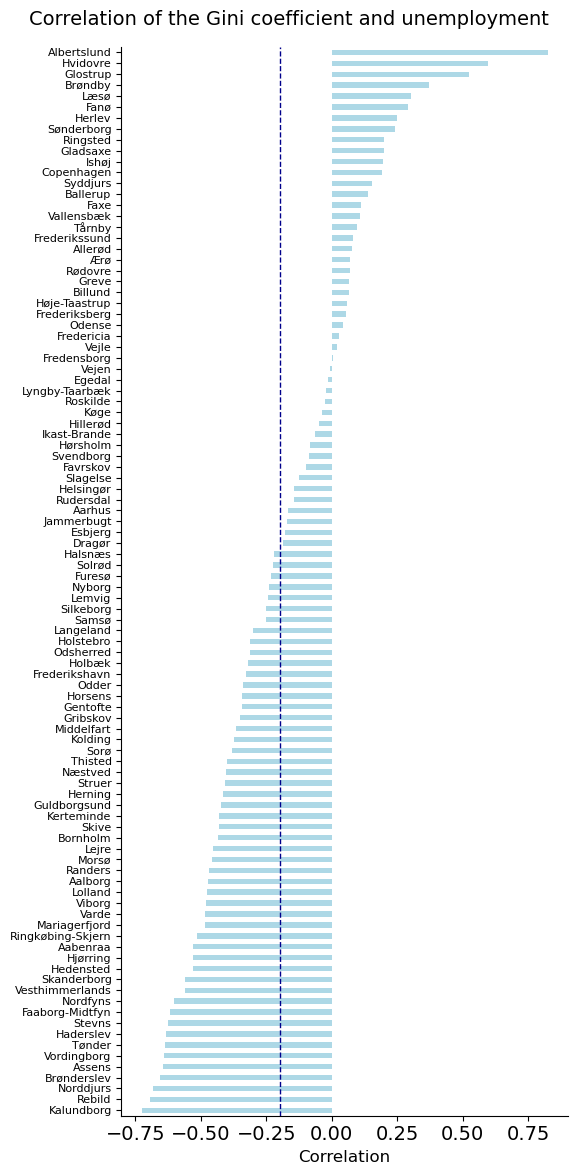

In [ ]:
# Plotting the correlation between the Gini coefficient and unemployment

fig, ax = plt.subplots(figsize=(6, 12))

ax.barh(corr1.index, corr1.values, height=0.5, color='lightblue')

ax.axvline(mean_correlation1, color='darkblue', linestyle='--', linewidth=1, label=f'Mean ={mean_correlation1:.2f}')

ax.set_xlabel('Correlation', fontsize=12)

ax.set_yticks(range(len(corr1.index)))
ax.set_yticks(np.arange(len(corr1.index)))
ax.set_yticklabels(corr1.index,fontsize=8)
ax.set_ylim(-0.5,len(corr1.index)-0.5)

ax.grid(False)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)


fig.suptitle('Correlation of the Gini coefficient and unemployment', fontsize=14)
fig.tight_layout()

The chart shows the correlation between the gini coefficient ant unemployment divided into the danish munitipalities. Most municipalities shows a negative correlation. Howeever, about a third of the municipalities show a possitive correlation. The mean of the correlation -0.198 which indicate a small negative correlation.

<h2> 2 Simulating the income distribution

### 2.1 The model

In [48]:
import pickle
import numpy as np

from scipy.stats import norm 

In [49]:
from income_simulation import simulate_income_distribution
from Gini import gini
import numpy as np

N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123

result = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)


ages = result['ages']
income = result['income']      
employed = result['employed']
e = result['education']

print(result) ##need to make prettier

#Check that the mean is one for the lognormal shock psi
rng_check = np.random.default_rng(seed)
psi_check = rng_check.lognormal(-0.5 * sigma_psi**2, sigma_psi, size=1_000_000)

print(f'Mean of psi: {psi_check.mean():.4f}')  # should be equal or close to 1.0

Mean of psi: 1.0001
{'ages': array([18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]), 'income': array([[0.45      , 0.45      , 0.45      , ..., 0.78061543, 0.75954873,
        0.8253255 ],
       [0.45      , 0.35      , 0.83498012, ..., 0.42095175, 0.43441942,
        0.42650798],
       [0.45      , 0.35      , 0.35      , ..., 0.7605678 , 0.92393649,
        1.05218231],
       ...,
       [0.45      , 0.45      , 0.45      , ..., 2.51647246, 2.07051497,
        2.00609383],
       [0.45      , 0.45      , 0.45      , ..., 2.44713031, 2.71745258,
        2.88679451],
       [0.45      , 0.35      , 1.09286273, ..., 2.81507515, 3.18277143,
        2.88798228]], shape=(50000, 48)), 'employed': array([[False, False, False, ...,  True,  True,  True],
       [False, False,  True, ...,  True,  True,  True],
       [False, False, Fal

### 2.2 Simulate the income distribution

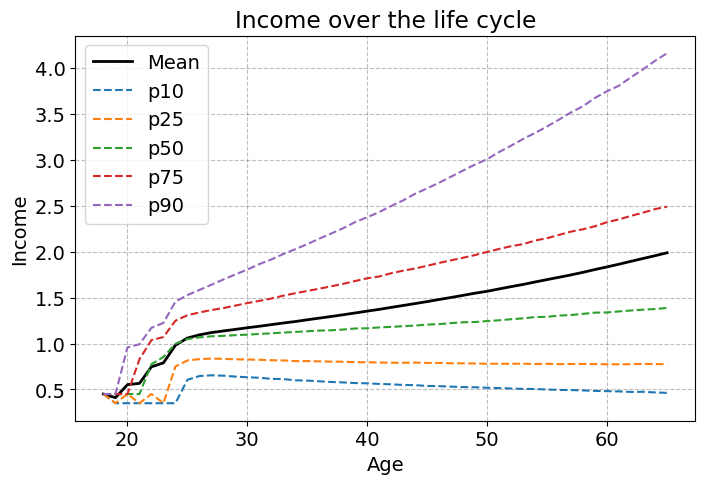

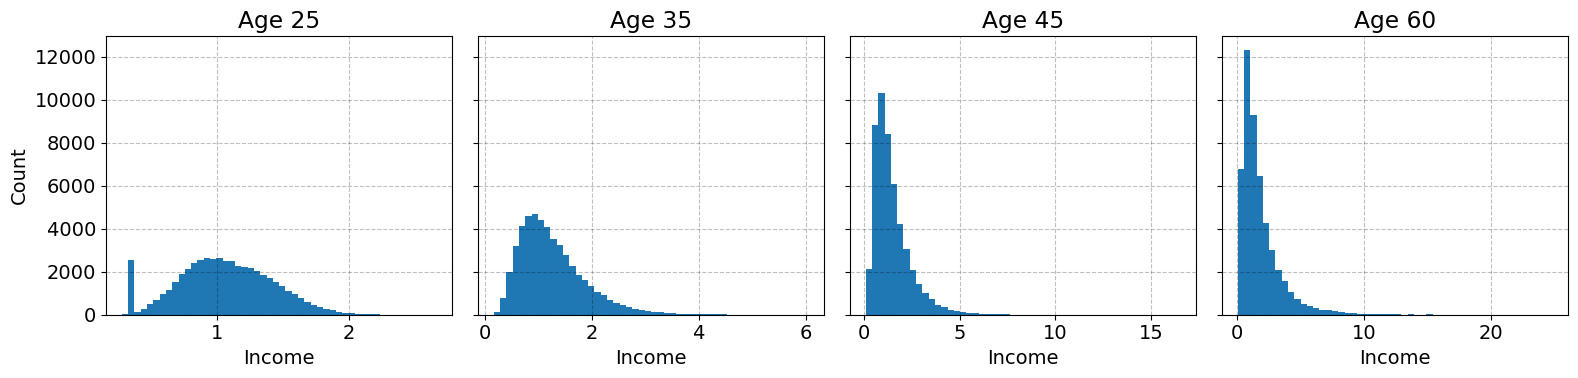

In [50]:

#Mean and selected percentiles of income over the life cycle

percentiles = [10, 25, 50, 75, 90]
income_percentiles = np.percentile(income, percentiles, axis=0)  # shape (5, T)
income_mean = income.mean(axis=0)

#life cycle of income plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages, income_mean, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles, income_percentiles):
    ax.plot(ages, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

#Income distribution histogram
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()



### 2.3 Compute the Gini coefficient

Uniform [0,1] test:   Gini = 0.3334   (target: 0.3333)
Lognormal(s=0.8) test: Gini = 0.4283   (target: 0.4284)


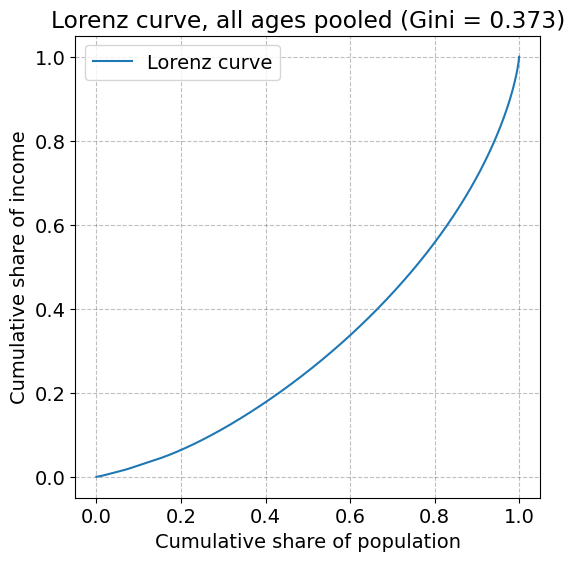

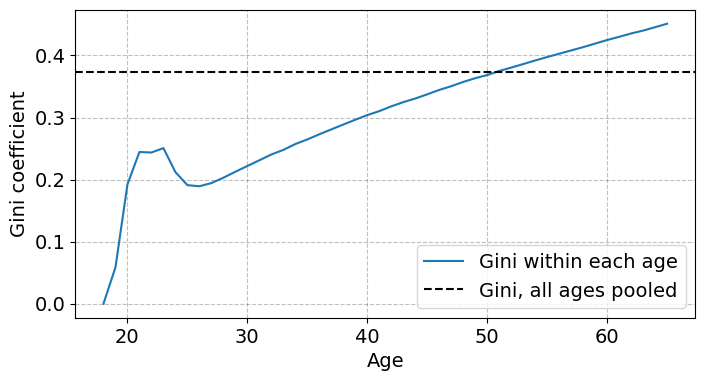

In [51]:
from Gini import gini #gini module
from scipy.stats import norm #normal distribution

#Test 1 with a known Gini coefficient of 1/3
test_rng = np.random.default_rng(0)
u = test_rng.uniform(0, 1, 1_000_000)
uniform_gini = gini(u)
print(f'Uniform [0,1] test:   Gini = {uniform_gini:.4f}   (target: {1/3:.4f})')

#Test 2 with std s and a known Gini coefficient of 2*Phi(s/sqrt(2)) - 1
s_test = 0.8
x_test = test_rng.lognormal(0, s_test, 1_000_000)
lognormal_gini = gini(x_test)
lognormal_target = 2 * norm.cdf(s_test / np.sqrt(2)) - 1
print(f'Lognormal(s={s_test}) test: Gini = {lognormal_gini:.4f}   (target: {lognormal_target:.4f})')

# pooled incomes across all simulated individuals and ages
pooled_income = income.ravel()
pooled_gini = gini(pooled_income)

#calculate cumulative values for Lorenz curve
def lorenz_curve(x):
    x_sorted = np.sort(x)
    cum_income = np.cumsum(x_sorted)
    cum_income_share = cum_income / cum_income[-1]
    cum_pop_share = np.arange(1, len(x) + 1) / len(x)
    return np.insert(cum_pop_share, 0, 0), np.insert(cum_income_share, 0, 0)

pop_share, inc_share = lorenz_curve(pooled_income)

#plot Lorenz curve
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(pop_share, inc_share, label='Lorenz curve')
ax.set_xlabel('Cumulative share of population')
ax.set_ylabel('Cumulative share of income')
ax.set_title(f'Lorenz curve, all ages pooled (Gini = {pooled_gini:.3f})')
ax.legend()
plt.show()

#Gini by age
gini_by_age = np.array([gini(income[:, t]) for t in range(len(ages))])

#plot different ages
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ages, gini_by_age, label='Gini within each age')
ax.axhline(pooled_gini, color='black', linestyle='--', label='Gini, all ages pooled')
ax.set_xlabel('Age')
ax.set_ylabel('Gini coefficient')
ax.legend()

Pooling ages together smooths the curve but overrepresents inequality by not holding age as a variable constant: pooled data is comparing younger, much lower-income earning groups with higher-earning older groups.

### 2.4 What drives inequality?

#### No education inequality
The inequality if everyone get´s a short education:

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.2955636357548791


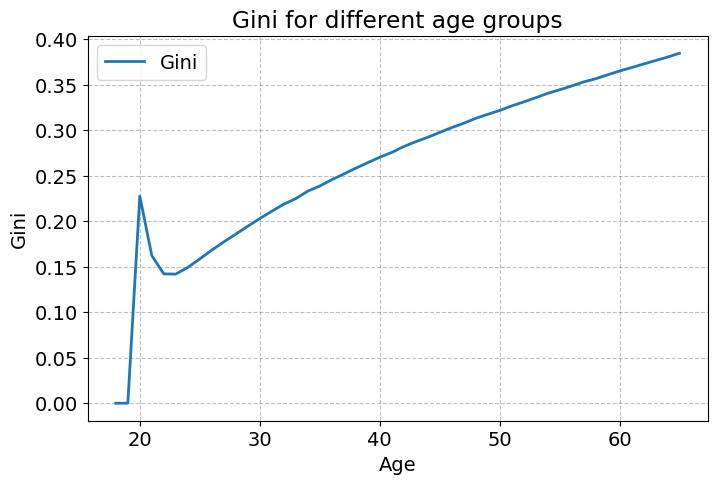

In [52]:
from Gini import gini

result_no_education_inequality = simulate_income_distribution(N, (1.0,0.0,0.0), s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_no_education_inequality = result_no_education_inequality['income']

def unwrap(x):
    unwraped= []
    for array in x:
        for element in array:
            unwraped.append(element)
    return unwraped

def incomeAtAge(income, age):
    atAge= []
    for array in income:
       atAge.append(array[age-age_min])
    return atAge


print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_no_education_inequality)))

def Gini_aged (switched_off_income):
    agedGini = []
    for age in ages:
        agedGini.append(gini(incomeAtAge(switched_off_income, age)))

    #Plotting "Gini for different age groups"
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ages, agedGini, linewidth=2, label='Gini')
    ax.set_xlabel('Age')
    ax.set_ylabel('Gini')
    ax.set_title('Gini for different age groups')
    ax.legend()
    plt.show()

Gini_aged(income_no_education_inequality)

#### No shock to human capital

Mean of psi: 1.0000
The Gini coefficient for all ages pooled is: 0.2736059135148775


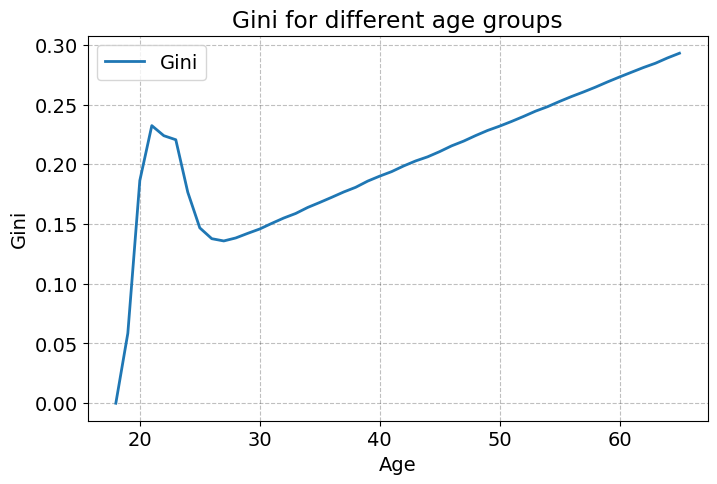

In [53]:
result_no_shock = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, 0.0,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_no_shock = result_no_shock['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_no_shock)))

Gini_aged(income_no_shock)

#### Depreciation of human capital while unemployed

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.37980741075126667


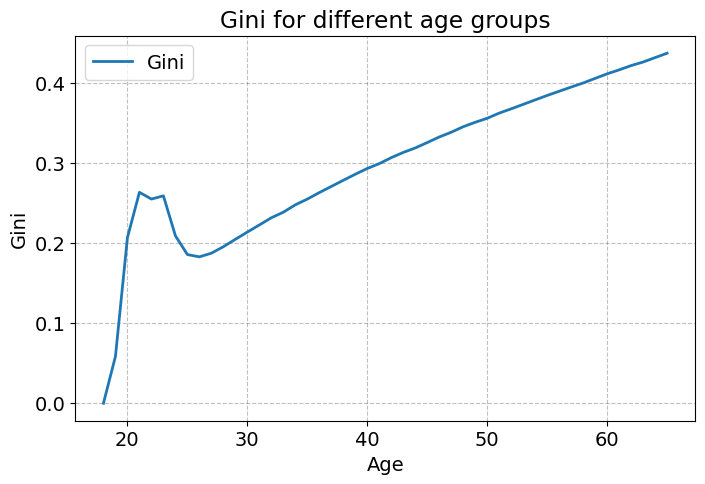

In [54]:
result_human_capital = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, 0.0, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_human_capital = result_human_capital['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_human_capital)))

Gini_aged(income_human_capital)

#### Unemplyment itself

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.37685512511680463


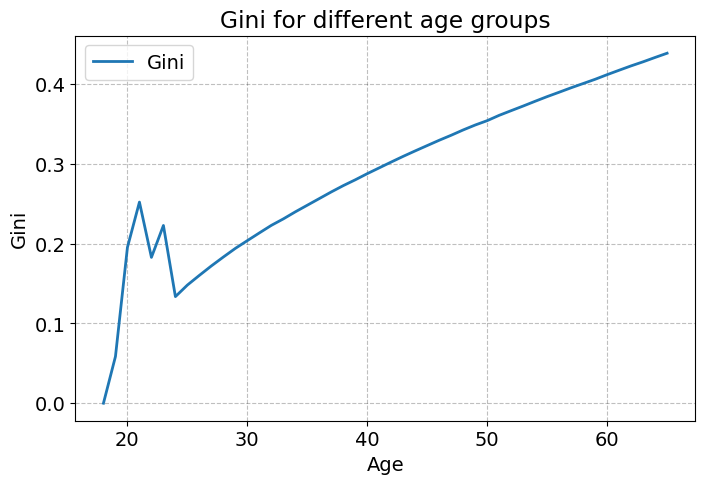

In [55]:
result_unemployment = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      1.0, 0.0, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_unemployment = result_unemployment['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_unemployment)))

Gini_aged(income_unemployment)

#### Without any changes in the variables

Mean of psi: 1.0001
The Gini coefficient for all ages pooled is: 0.3727564691326209


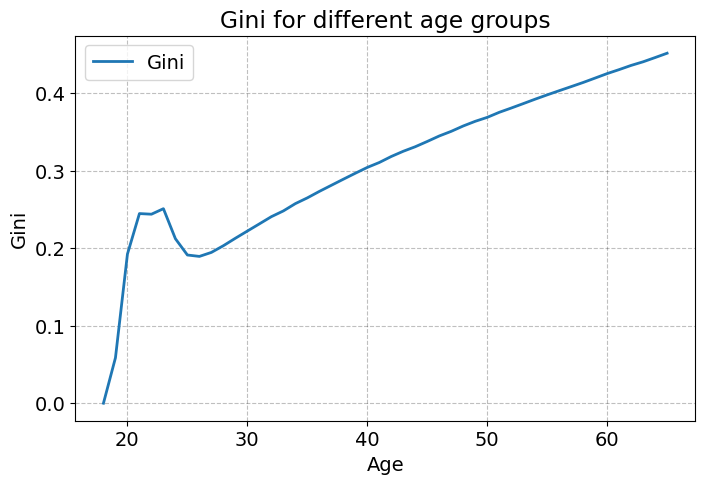

In [56]:
result_udg = simulate_income_distribution(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed)

income_udg = result_udg['income']

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_udg)))

Gini_aged(income_udg)

Overall the gini coefficient is larger for people in their twenties. A reason for this might be how fast people get a job. The first graph whith no education inequality shows that if everyone got the same education then the inequality would still be large in the beginning but for a shorter timeperiod compared to the other cases where people have different length of education. After the spike in the twenties, then people will become more equal and afterwards less equal again. This trend might come because of growth in human capital which increases more for people with a longer education. The human capital is the same as the income in the model when employed.

#### Which mechanism matters the most?
With no differences made, the gini coefficient is 0.373. The first experiment "No education inequality" made the gini coefficient smaller to 0.296 and therefore the society more equal. The second experiment "No shock to human capital" becomes the lowest gini coefficient of all the experiments with a gini at 0.274. The third experiment "Depreciation of human capital while unemployed" makes the society more unequal and the gini coefficient is now 0.380. The fourth experiment is also making the society more unequal and the gini in this case is 0.377.
The mechanism that matters the most to get a equal society is then the second experiment "No shock to human capital".

### 2.5 Extension: more risk

In [57]:
"""
If something happens, so you cannot work anymore, then you can get a disability pension, y_dis, where your income then will be y_dis=0.6
The probability of becoming disabled is p_dis=0.02
"""
from income_simulation_disabled import simulate_income_distribution_disabled

N=50000
p_e=(0.4,0.35,0.25)
s_e=(1,3,5)
h_e0=(1.00,1.20,1.55)
delta_e=(0.010,0.020,0.030)
delta=(0.06)
sigma_psi=0.1
lambda_psi=0.6
sigma=0.05
y_su=0.45
rho=0.60
y_floor=0.35
age_min=18
age_max=65
seed=123
y_dis=0.6
p_dis=0.02


result_ext = simulate_income_distribution_disabled(N, p_e, s_e, h_e0, delta_e, delta, sigma_psi,
                                      lambda_psi, sigma, y_su, rho, y_floor,
                                       age_min, age_max, seed, y_dis, p_dis)


ages_ext = result_ext['ages']
income_ext = result_ext['income']      
employed_ext = result_ext['employed']
e_ext = result_ext['education']

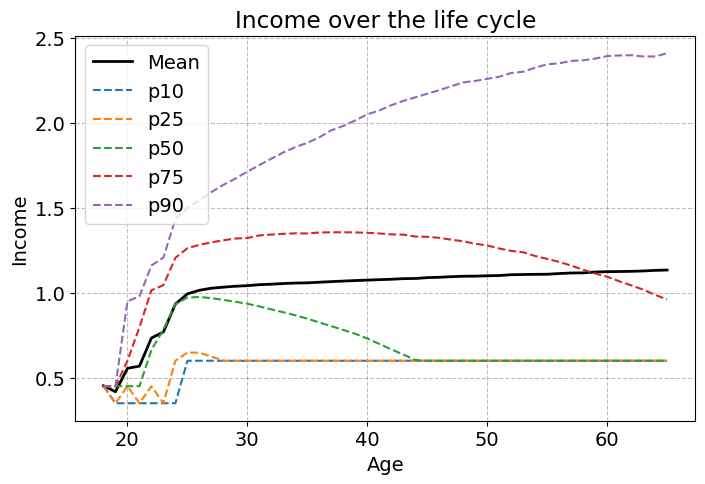

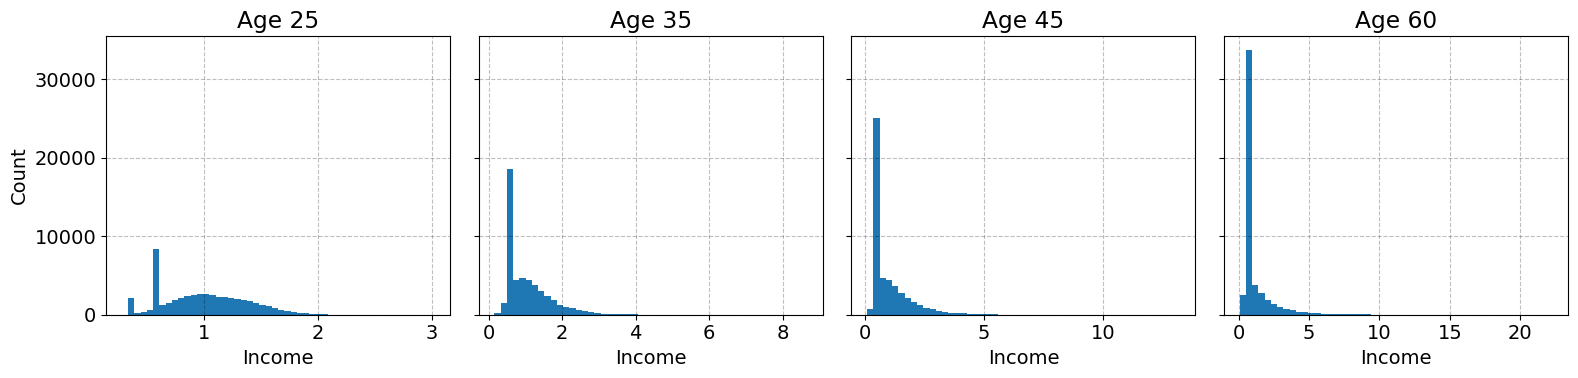

In [58]:
# Mean and selected percentiles of income over the life cycle

percentiles_ext = [10, 25, 50, 75, 90]
income_percentiles_ext = np.percentile(income_ext, percentiles_ext, axis=0)  # shape (5, T)
income_mean_ext = income_ext.mean(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ages_ext, income_mean_ext, label='Mean', linewidth=2, color='black')
for p, series in zip(percentiles_ext, income_percentiles_ext):
    ax.plot(ages_ext, series, label=f'p{p}', linestyle='--')
ax.set_xlabel('Age')
ax.set_ylabel('Income')
ax.set_title('Income over the life cycle')
ax.legend()
plt.show()

# Histograms of the income distribution at selected ages
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, age in zip(axes, [25, 35, 45, 60]):
    idx = age - age_min  # column index for this age
    ax.hist(income_ext[:, idx], bins=50)
    ax.set_title(f'Age {age}')
    ax.set_xlabel('Income')
axes[0].set_ylabel('Count')
fig.tight_layout()
plt.show()

The Gini coefficient for all ages pooled is: 0.3493292352849581


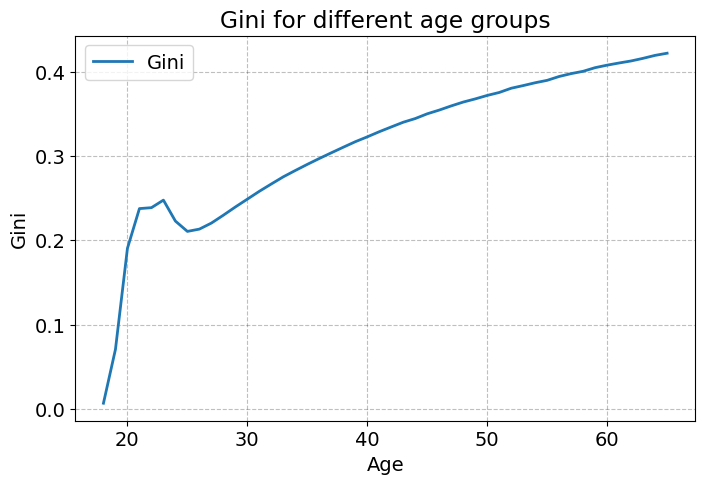

In [59]:
#Calculating gini

print("The Gini coefficient for all ages pooled is:", gini(unwrap(income_ext)))

Gini_aged(income_ext)

#### Extend the model with another source of risk of your own choosing, and analyze how it changes the income distribution and the Gini coefficient.

The gini coefficient graph looks very similar to the graph before adding the disable pension.
The difference after adding the disable pension clearly can be seen at the graph called "income over the life cycle". Instead of the income is just increasing as before, it is now decreasing for all groups and the percentiles looks more like a parable instead of an exponential function.
The mean in "income over the life cycle" is also more stabil in the new simulation compared to the old simulation where the mean also was increasing.